In [24]:
#Random Search ile Hiperparametre Optimizasyonu

Bu projede Random Search yöntemi kullanılarak model için en uygun hiperparametreler belirlenmiştir.

## Test Sonuçları
Bu bölümde Random Search sonucunda elde edilen en iyi model test verisi üzerinde değerlendirilmiştir.

In [25]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Test doğruluk oranı:", accuracy)

Test doğruluk oranı: 1.0


## Performans Değerlendirmesi
Bu bölümde modelin sınıflandırma raporu ve karışıklık matrisi gösterilmiştir.

In [26]:
print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("Karışıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Karışıklık Matrisi:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


## Sonuçların Görselleştirilmesi
Bu bölümde Random Search sonuçları grafik ile gösterilmiştir.

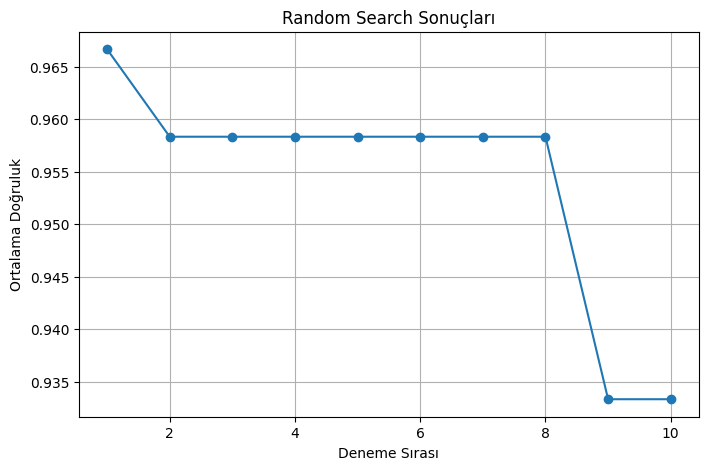

In [27]:
results = p.DataFrame(random_search.cv_results_)
results = results.sort_values("rank_test_score")

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), results["mean_test_score"].head(10), marker="o")
plt.xlabel("Deneme Sırası")
plt.ylabel("Ortalama Doğruluk")
plt.title("Random Search Sonuçları")
plt.grid(True)
plt.show()

In [28]:
import numpy as np
import pandas as p
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Veri Yükleme
Bu bölümde Iris veri seti sisteme yüklenmiştir.

In [29]:
iris = load_iris()
X = iris.data
y = iris.target

print("Veri boyutu:", X.shape)
print("Sınıf sayısı:", len(np.unique(y)))

Veri boyutu: (150, 4)
Sınıf sayısı: 3


## Veri Ön İşleme
Bu bölümde veri eğitim ve test olarak ayrılmış ve modelin daha sağlıklı çalışabilmesi için ölçeklendirme işlemi uygulanmıştır.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Eğitim veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)

Eğitim veri boyutu: (120, 4)
Test veri boyutu: (30, 4)


## Model Kurulumu
Bu bölümde KNN modeli oluşturulmuştur.

In [31]:
model = KNeighborsClassifier()

## Hiperparametrelerin Belirlenmesi
Bu bölümde Random Search için kullanılacak parametre aralıkları tanımlanmıştır.

In [32]:
param_dist = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

## Random Search Uygulaması
Bu bölümde farklı hiperparametre kombinasyonları denenmiştir.

In [33]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("En iyi parametreler:", random_search.best_params_)
print("En iyi skor:", random_search.best_score_)

En iyi parametreler: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'minkowski'}
En iyi skor: 0.9666666666666668


## Test Sonuçları
Bu bölümde Random Search sonucunda elde edilen en iyi model test verisi üzerinde değerlendirilmiştir.

In [34]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Test doğruluk oranı:", accuracy)

Test doğruluk oranı: 1.0


## Performans Değerlendirmesi
Bu bölümde modelin performansı detaylı olarak incelenmiştir.

In [35]:
print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("Karışıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Karışıklık Matrisi:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


## Genel Değerlendirme

Bu çalışmada Random Search yöntemi kullanılarak KNN modeli için en uygun hiperparametreler belirlenmiştir. Elde edilen sonuçlara göre hiperparametre seçiminin model performansı üzerinde önemli bir etkisi olduğu görülmüştür. En iyi parametre kombinasyonu ile model yüksek doğruluk değerine ulaşmıştır.
